In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

nsim = 10 # number of simulations

In [3]:
ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)
p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [4]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [5]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

SASA_unphos = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/hbonds/dat/surf.dat', **params)
SASA_phos = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/hbonds/dat/surf_ser5.dat', **params)

In [6]:
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')
ctd_unphos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')

In [7]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

df_360_unphos = ctd_unphos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_unphos:
    df_360_unphos.loc[df_360_unphos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_unphos[col] = round(df_360_unphos[col])  # Round angles to the nearest integer

In [8]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()
ctd_unphos_omega_angles = df_360_unphos.copy()

In [9]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

# labelling configurationgs of omega angles
temp_angles = ctd_unphos_omega_angles.copy()

ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_unphos_omega_angles[(ctd_unphos_omega_angles.iloc[:,1:] != "cis") & (ctd_unphos_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_1718870/3533782883.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
/tmp/ipykernel_1718870/3533782883.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_unphos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [10]:
ser5_SASA_unphos = pd.DataFrame(SASA_unphos['SA_00014'])
ser5_SASA_phos = pd.DataFrame(SASA_phos['SA_00001'])

In [11]:
ser5_SASA_phos = ser5_SASA_phos.reset_index(drop=True)
ser5_SASA_phos_cistrans = ser5_SASA_phos.copy()
ser5_SASA_phos_cistrans['cis/trans/neither'] = ctd_phos_omega_angles['omega:14']

ser5_SASA_unphos = ser5_SASA_unphos.reset_index(drop=True)
ser5_SASA_unphos_cistrans = ser5_SASA_unphos.copy()
ser5_SASA_unphos_cistrans['cis/trans/neither'] = ctd_unphos_omega_angles['omega:14']

In [12]:
ser5_SASA_unphos_cistrans['weights'] = ctd_weights_combined[0]
ser5_SASA_phos_cistrans['weights'] = p_ctd_weights_combined[0]

In [13]:
ser5_SASA_unphos_cistrans

,SA_00014,cis/trans/neither,weights
0,96.0626,cis,2.068308e-08
1,97.7264,cis,8.310223e-09
2,100.0050,cis,1.665468e-08
3,97.3044,cis,4.747710e-08
4,95.6249,cis,1.088663e-08
...,...,...,...
47999995,35.3662,trans,1.861614e-08
47999996,37.8484,trans,1.241771e-08
47999997,39.1536,trans,1.139632e-08
47999998,36.5160,trans,5.317541e-09


# Phosphorylated

## Pro6 in cis

In [14]:
pmean_cis = np.average((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00001'], weights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'])

pstd_cis = np.sqrt(np.cov((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00001'], aweights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("pmean: {}".format(pmean_cis))
print("pstd: {}".format(pstd_cis))

pmean: 176.16540009702524
pstd: 25.66597293501946


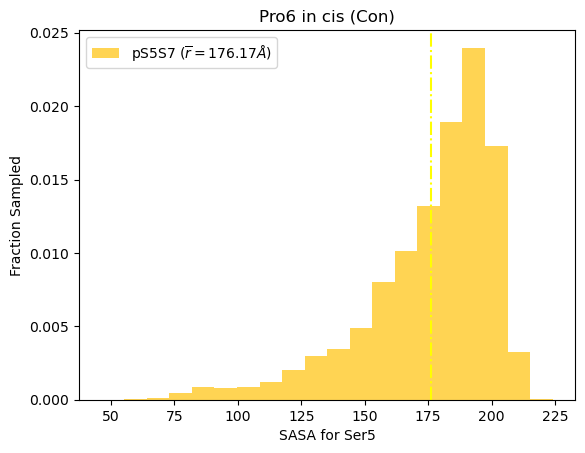

In [15]:
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00001'], bins=20, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_cis, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_cis, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in cis (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## Pro6 in trans

In [16]:
pmean_trans = np.average((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00001'], weights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'])

pstd_trans = np.sqrt(np.cov((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00001'], aweights=(ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("pmean: {}".format(pmean_trans))
print("pstd: {}".format(pstd_trans))

pmean: 162.84078115811784
pstd: 26.878204987866607


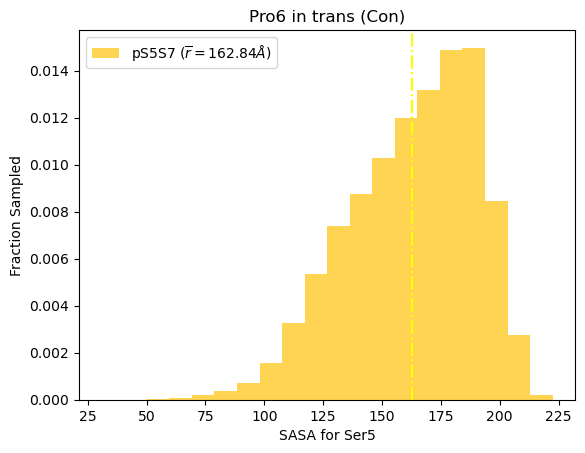

In [17]:
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00001'], bins=20, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_trans, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_trans, color='yellow', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in trans (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## cis and trans together

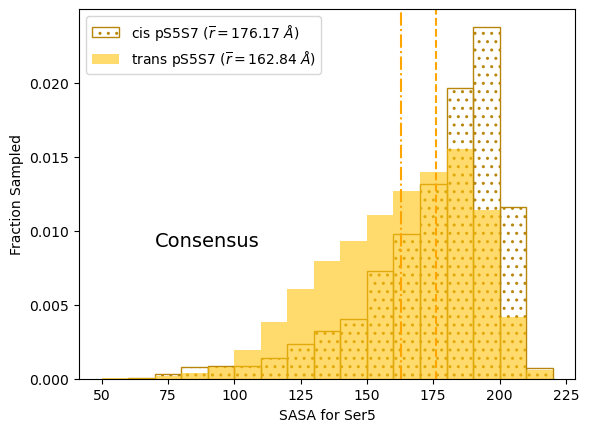

In [46]:
binedges = np.arange(50,225,10)

plt.figure()
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['SA_00001'], bins=binedges, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True, edgecolor="darkgoldenrod", color = '#FFC20A', fill=None, hatch='..', label=r"cis pS5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_cis, 2)), alpha=1)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_cis, color='orange', ls='--')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')
plt.hist((ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['SA_00001'], bins=binedges, weights = (ser5_SASA_phos_cistrans[ser5_SASA_phos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"trans pS5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_trans, 2)), alpha=0.6)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(pmean_trans, color='orange', ls='-.')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
#plt.title('Consensus Phosphorylated')
plt.legend(loc="upper left", fontsize=10)
plt.text(70, 0.01, 'Consensus', fontsize=14, verticalalignment='top')
plt.show()

# Unphosphorylated

## Pro6 in cis

In [37]:
mean_cis = np.average((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], weights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'])

std_cis = np.sqrt(np.cov((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], aweights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("mean: {}".format(mean_cis))
print("std: {}".format(std_cis))

mean: 90.73690375123189
std: 23.880926644209985


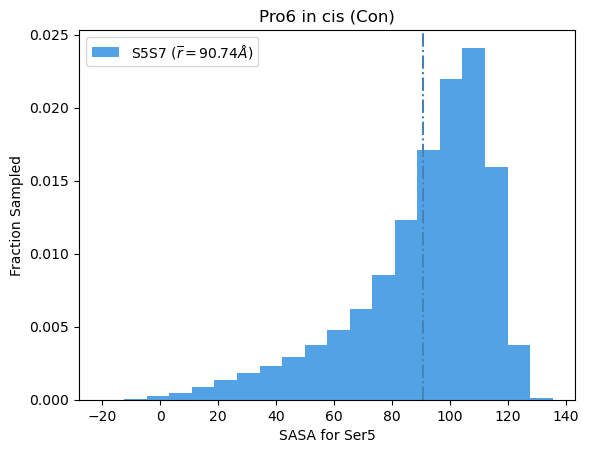

In [38]:
plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=20, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#0C7BDC", label=r"S5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(mean_cis, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_cis, color='steelblue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in cis (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## Pro6 in trans

In [39]:
mean_trans = np.average((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], weights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'])

std_trans = np.sqrt(np.cov((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], aweights=(ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("mean: {}".format(mean_trans))
print("std: {}".format(std_trans))

mean: 71.24981893932022
std: 27.475917703884186


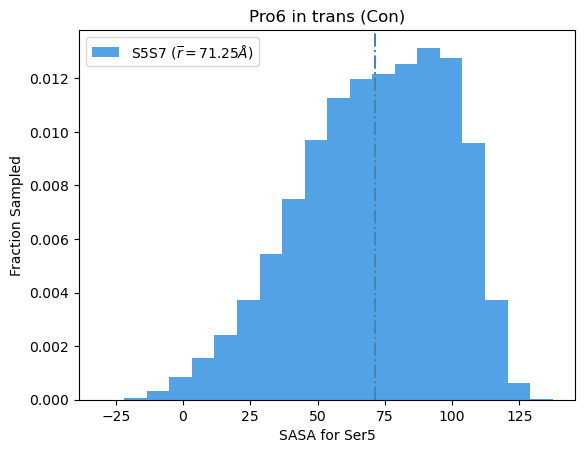

In [40]:
plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=20, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#0C7BDC", label=r"S5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(mean_trans, 2)), alpha=0.7)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_trans, color='steelblue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
plt.title('Pro6 in trans (Con)')
plt.legend(loc="upper left", fontsize=10)
plt.show()

## cis and trans together

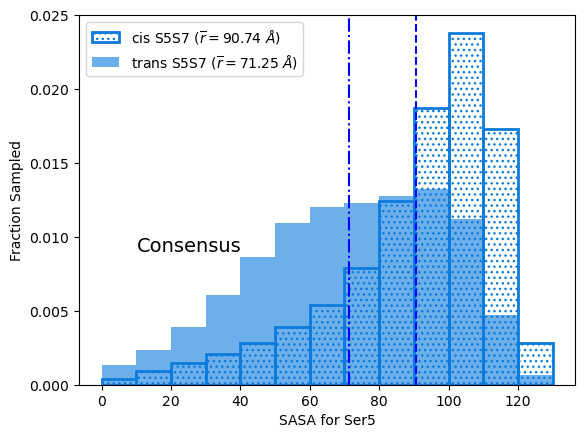

In [48]:
binedges = np.arange(0,135,10)

plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['SA_00014'], bins=binedges, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#0C7BDC", linewidth=2, fill=None, hatch='...', edgecolor="#0C7BDC", label=r"cis S5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(mean_cis, 2)), alpha=1)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_cis, color='blue', ls='--')

plt.hist((ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['SA_00014'], bins=binedges, weights = (ser5_SASA_unphos_cistrans[ser5_SASA_unphos_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#0C7BDC", label=r"trans S5S7 ($\overline{r} = $"+"{} $\AA$)".format(round(mean_trans, 2)), alpha=0.6)

#plt.axvline(npmean, color='steelblue', ls='--')
plt.axvline(mean_trans, color='blue', ls='-.')
#plt.ylim([0, 0.45])
#plt.xlim([3,8])
# plt.text(15.5, 0.24, r"$\overline{r_{unphos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{ununphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD unphos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('SASA for Ser5')
#plt.title('Consensus Unphosphorylated')
plt.legend(loc="upper left", fontsize=10)
plt.text(10, 0.01, 'Consensus', fontsize=14, verticalalignment='top')
plt.show()